# 6. Results analysis

For each model:

* 7 subplots (one per ion)
    * X: n_features
    * Y: mean MAE
    * error bars: std
    * curves for the basis expansions
        * baseline:
        * horizontal mean line
        * translucent standard-deviation band

In [1]:
RESULTS_PATH = "results/Experiment_1_3.json"
BASELINE_PATH = "results/Baseline_1_3.json"
CACHE_DIR = "cache_features"

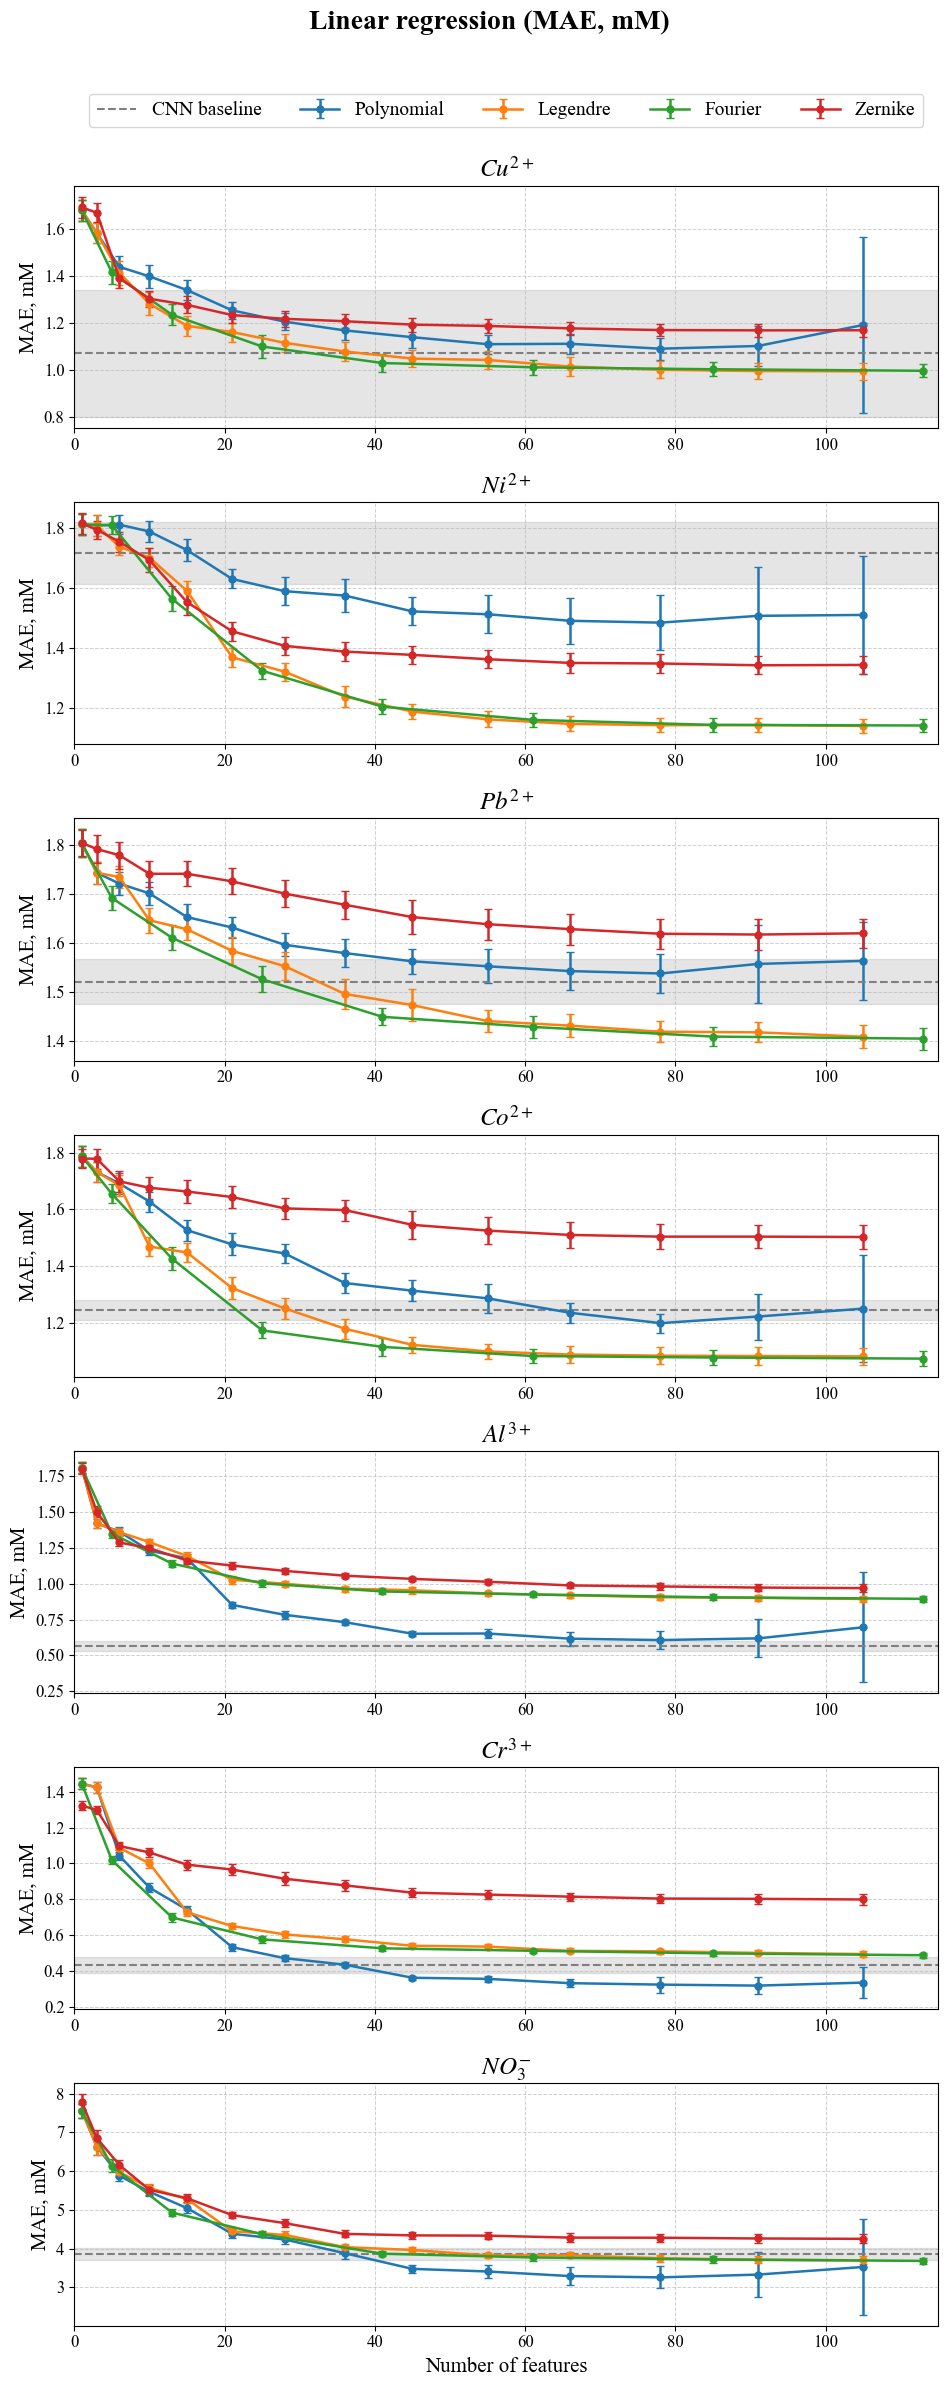

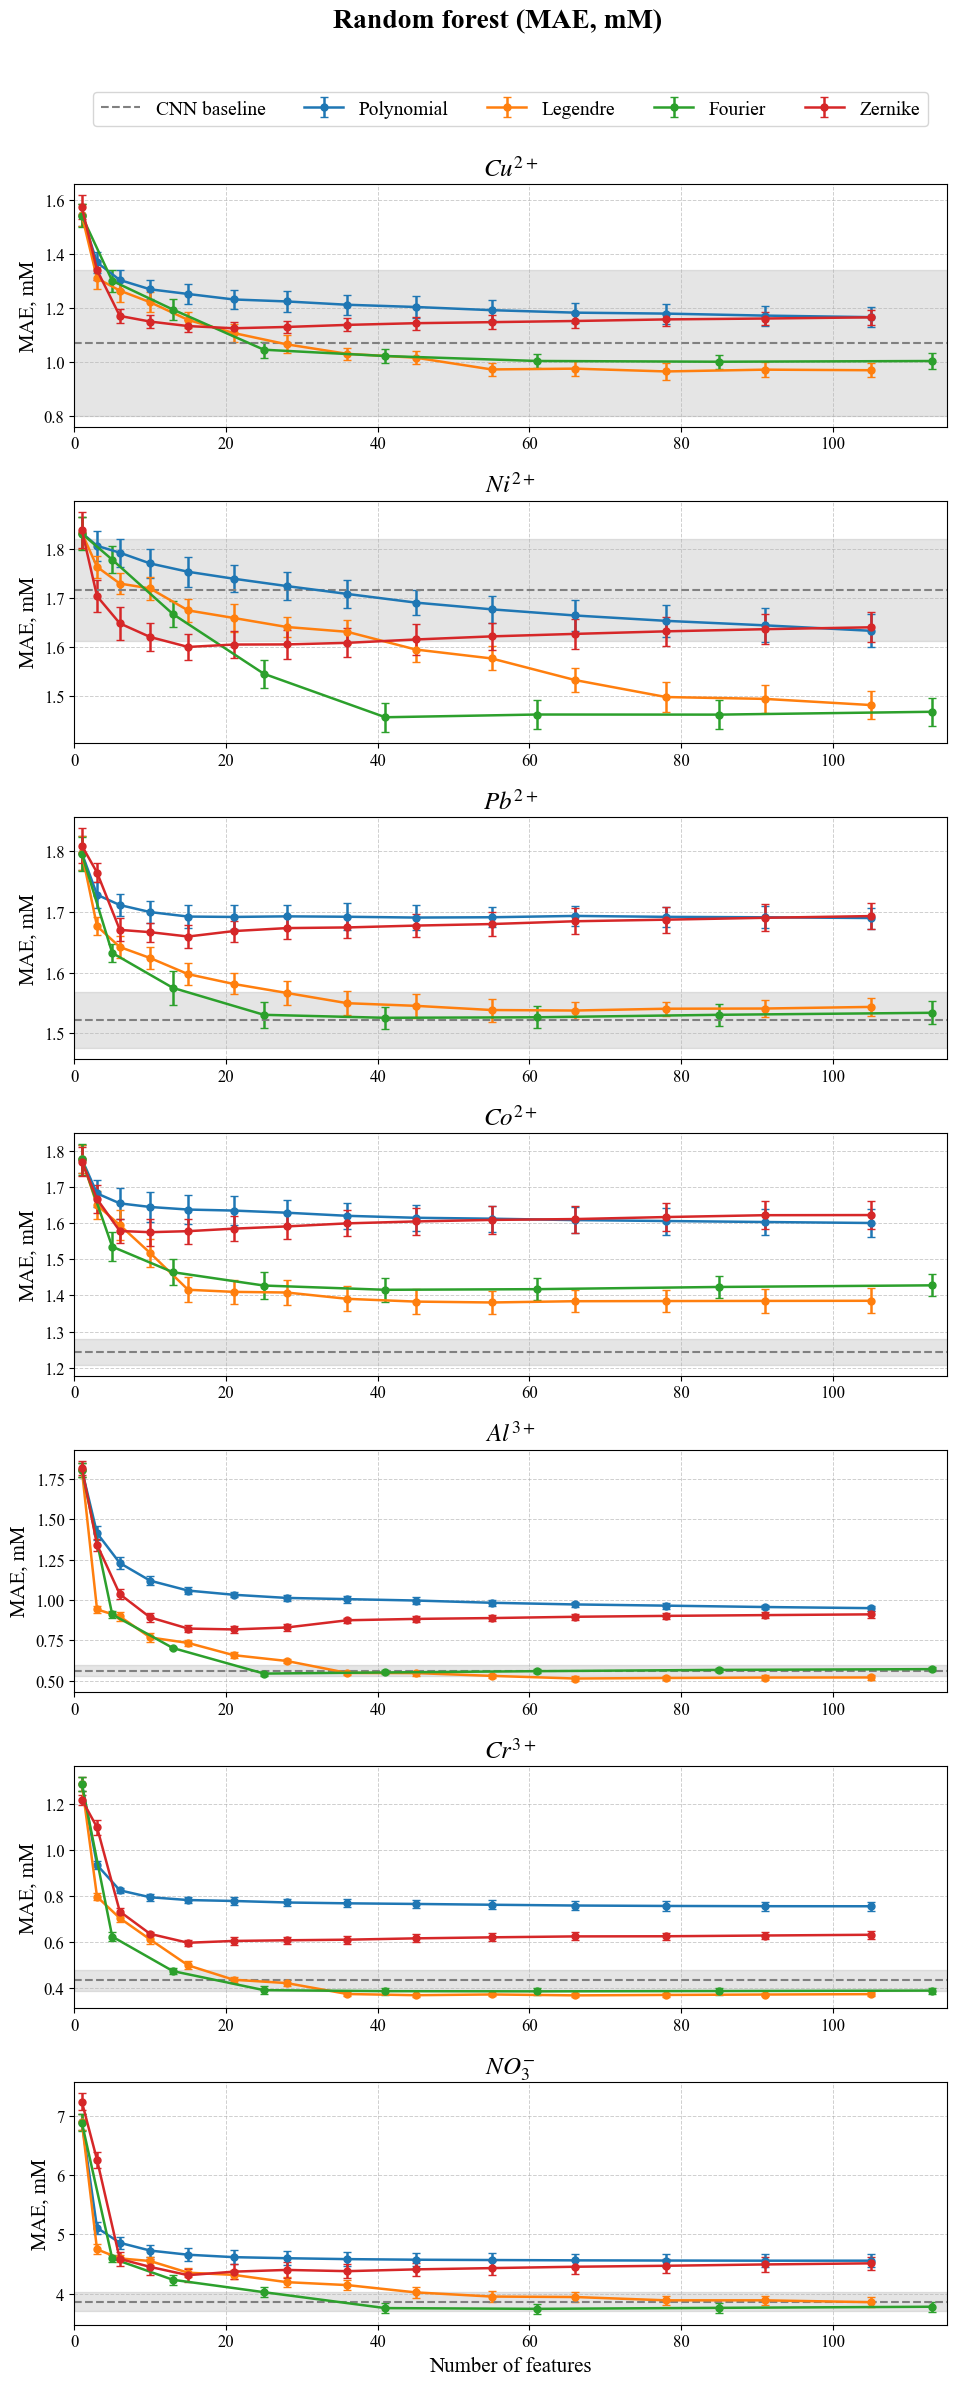

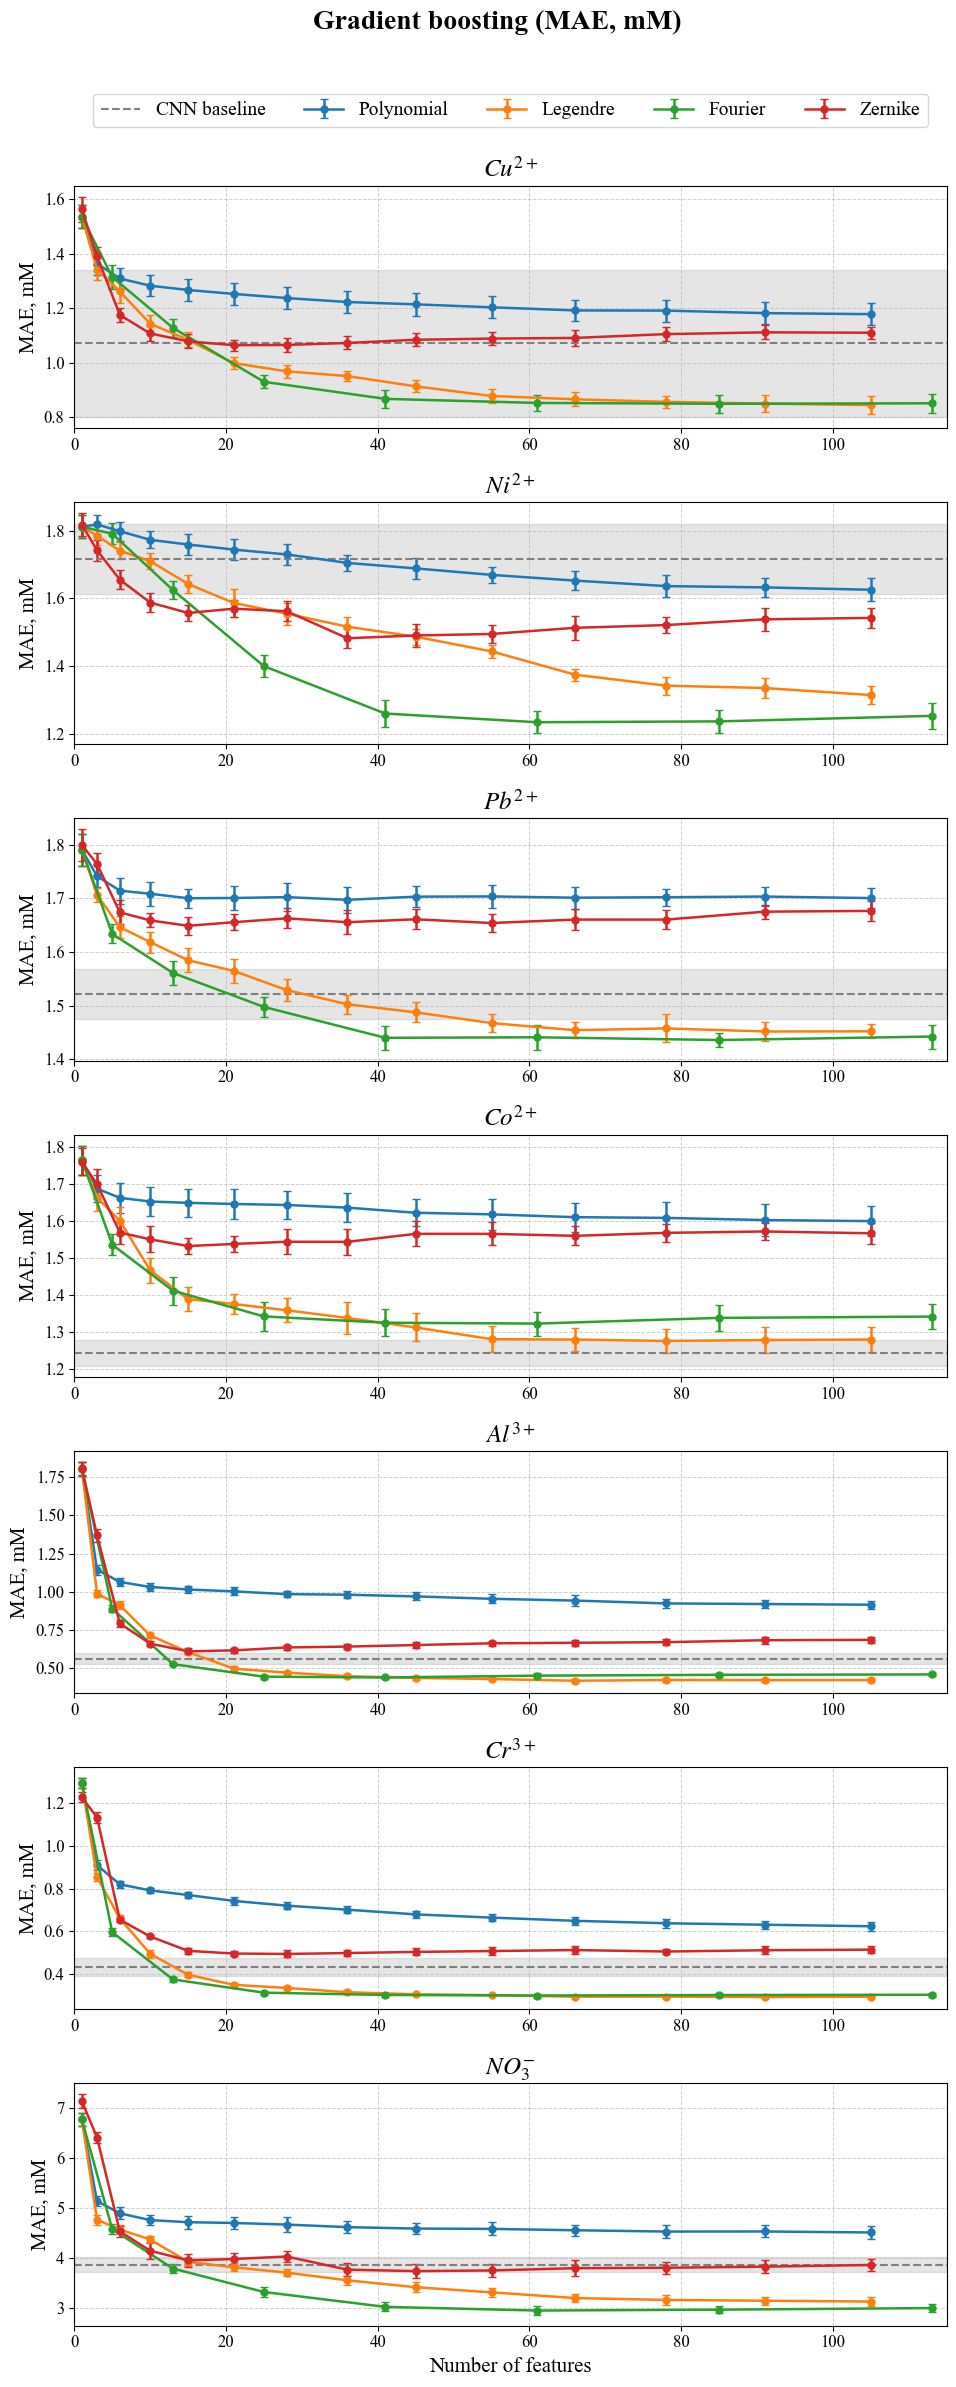

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ==================================================
# SELECT METRIC HERE
# ==================================================
METRIC = "MAE"      # "MAE", "RMSE", "R2"

# ==================================================
# SEABORN PRESETS
# ==================================================
# sns.set_theme(style="whitegrid", context="poster")
# sns.set_theme(style="whitegrid", context="paper")

# ==================================================
# GLOBAL STYLE
# ==================================================
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"

mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 15
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12

# ==================================================
# AXIS LABELS BY METRIC
# ==================================================
metric_ylabel = {
    "MAE": "MAE, mM",
    "RMSE": "RMSE, mM",
    "R2": r"$R^{2}$"
}

# ==================================================
# SETTINGS
# ==================================================
XMIN, XMAX = 0, 115

models = {
    "LR": "Linear regression",
    "RF": "Random forest",
    "GB": "Gradient boosting",
    # "MLP": "Multilayer Perceptron"
}

momenta = ["momentum", "legendre", "fourier", "zernike"]

ions = ["Cu", "Ni", "Pb", "Co", "Al", "Cr", "NO3"]

ion_titles = {
    "Cu":  r"$Cu^{2+}$",
    "Ni":  r"$Ni^{2+}$",
    "Pb":  r"$Pb^{2+}$",
    "Co":  r"$Co^{2+}$",
    "Al":  r"$Al^{3+}$",
    "Cr":  r"$Cr^{3+}$",
    "NO3": r"$NO_{3}^{-}$"
}
ion_titles = {
    "Cu":  r"$Cu^{2+}$",
    "Ni":  r"$Ni^{2+}$",
    "Pb":  r"$Pb^{2+}$",
    "Co":  r"$Co^{2+}$",
    "Al":  r"$Al^{3+}$",
    "Cr":  r"$Cr^{3+}$",
    "NO3": r"$NO_{3}^{-}$"
}

colors = {
    "momentum": "#1f77b4",
    "legendre": "#ff7f0e",
    "fourier":  "#2ca02c",
    "zernike":  "#d62728"
}

translate = {
    "momentum": "Polynomial",
    "legendre": "Legendre",
    "fourier":  "Fourier",
    "zernike":  "Zernike"
}

# ==================================================
# LOAD DATA
# ==================================================
with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

with open(BASELINE_PATH, "r") as f:
    baseline = json.load(f)

# ==================================================
# PLOT
# ==================================================
for model_key, model_title in models.items():

    if model_key not in results:
        continue

    fig, axes = plt.subplots(
        nrows=7,
        ncols=1,
        figsize=(10, 24),
        sharex=True
    )

    fig.suptitle(
        f"{model_title} ({metric_ylabel[METRIC]})",
        fontsize=20,
        fontweight="bold",
        y=0.995
    )

    for i, ion in enumerate(ions):

        ax = axes[i]

        # ------------------------------------------
        # Plot curves
        # ------------------------------------------
        for mom in momenta:

            if ion not in results[model_key][mom]:
                continue

            xs, ys, errs = [], [], []

            feature_keys = sorted(
                results[model_key][mom][ion].keys(),
                key=lambda x: int(x)
            )

            for n_feat in feature_keys:

                vals = np.array(
                    results[model_key][mom][ion][n_feat][METRIC]
                )

                xs.append(int(n_feat))
                ys.append(np.mean(vals))
                errs.append(np.std(vals))

            if len(xs) == 0:
                continue

            ax.errorbar(
                xs,
                ys,
                yerr=errs,
                marker="o",
                lw=1.8,
                ms=5,
                capsize=3,
                color=colors[mom],
                label=translate[mom]
            )

        # ------------------------------------------
        # CNN baseline
        # ------------------------------------------
        baseline_vals = np.array(baseline[ion][METRIC])

        baseline_mean = np.mean(baseline_vals)
        baseline_std  = np.std(baseline_vals)

        ax.axhline(
            baseline_mean,
            color="gray",
            linestyle="--",
            linewidth=1.5,
            label="CNN baseline"
        )

        ax.fill_between(
            [XMIN, XMAX],
            baseline_mean - baseline_std,
            baseline_mean + baseline_std,
            color="gray",
            alpha=0.20
        )

        # ------------------------------------------
        # Axes / grid
        # ------------------------------------------
        ax.set_xlim(XMIN, XMAX)

        ax.grid(
            which="major",
            axis="both",
            linestyle="--",
            linewidth=0.7,
            alpha=0.6
        )

        # Optional useful limits for R2
        if METRIC == "R2":
            ax.set_ylim(0, 1.05)

        ax.set_title(ion_titles[ion], pad=6)
        ax.set_ylabel(metric_ylabel[METRIC])

        # x labels on every subplot
        ax.tick_params(axis="x", labelbottom=True)

        # legend only first subplot
        if i == 0:
            ax.legend(
                ncol=5,
                loc="upper center",
                bbox_to_anchor=(0.5, 1.42),
                frameon=True
            )

    axes[-1].set_xlabel("Number of features")

    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

In [3]:
np.mean(baseline['NO3']['MAE'])

np.float64(3.8648055475187113)

In [4]:
np.mean(results['GB']['legendre']['NO3']['78']['MAE'])

np.float64(3.155616343485822)

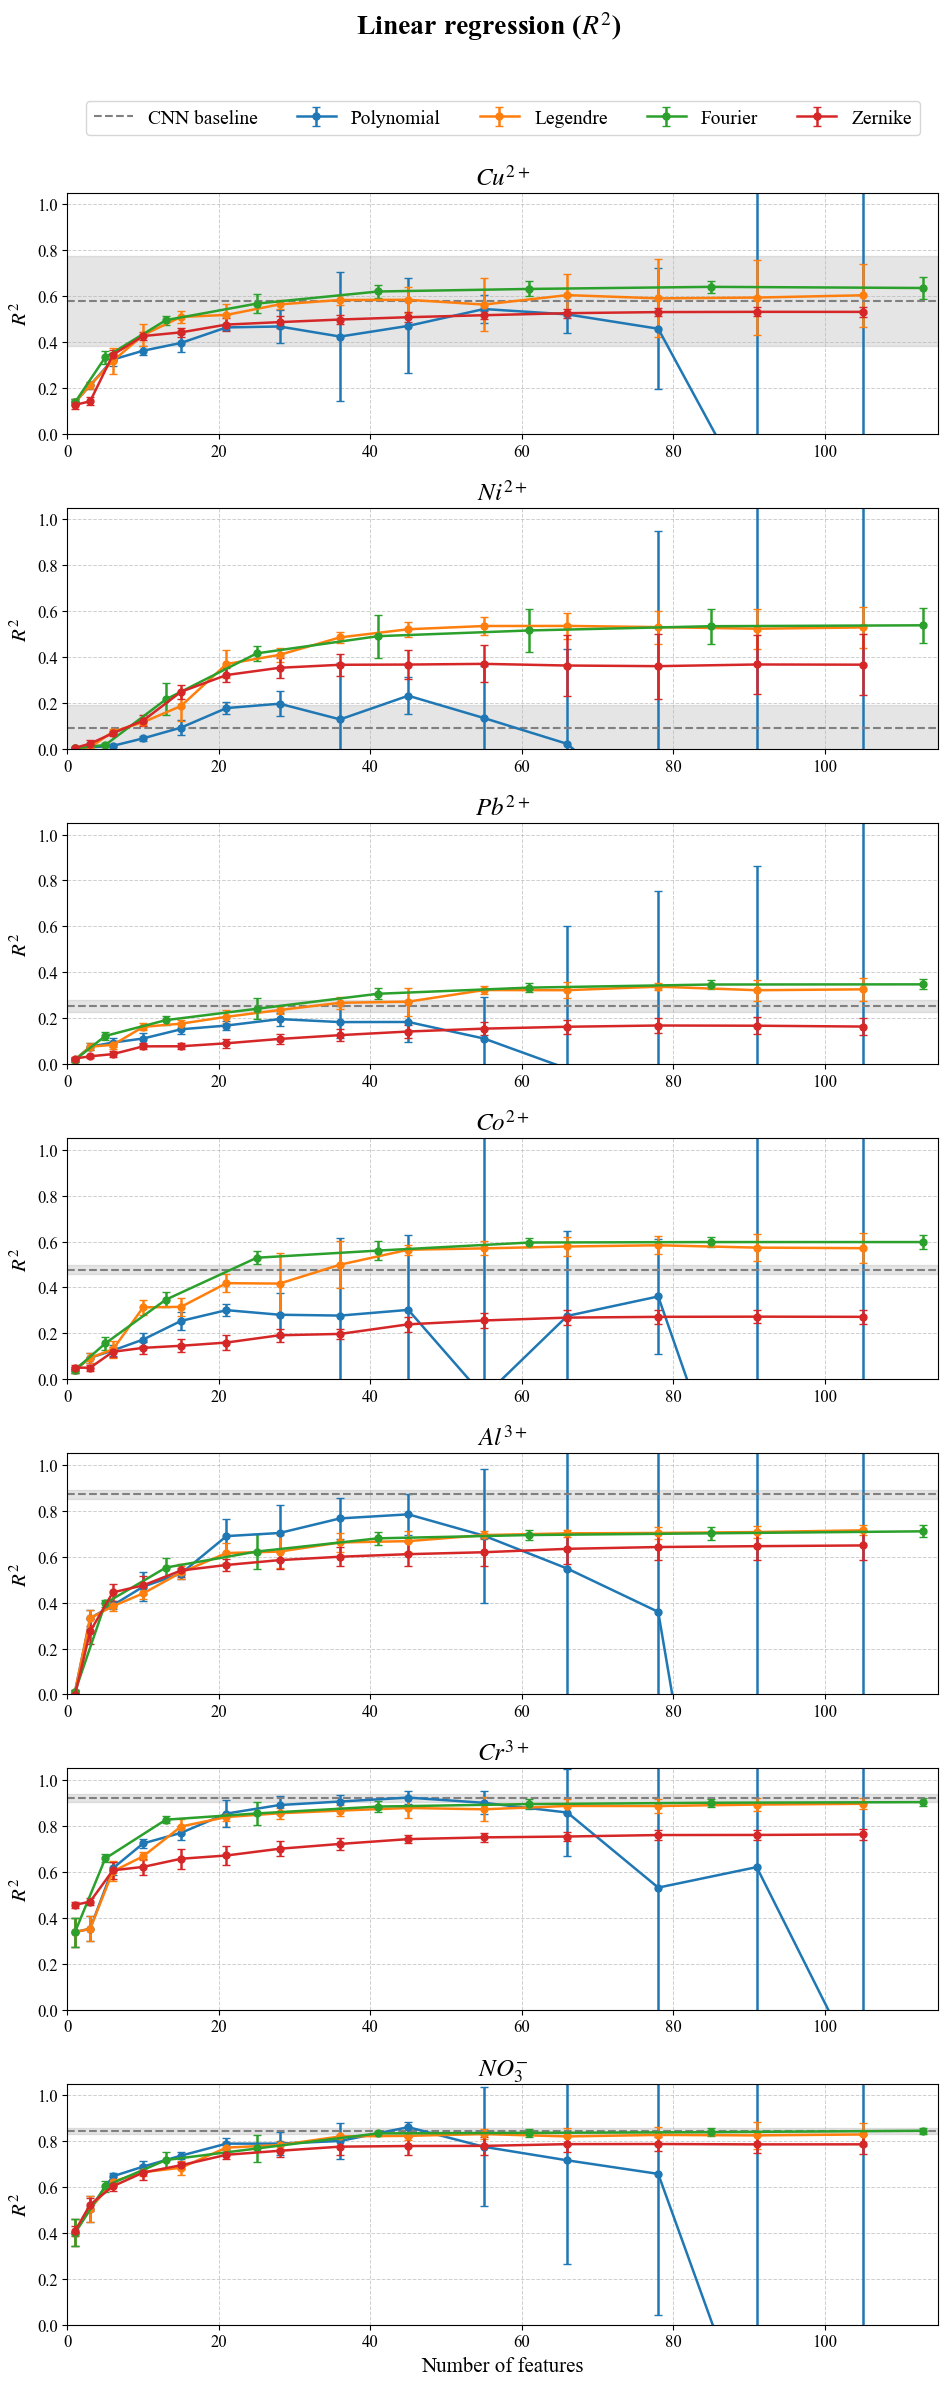

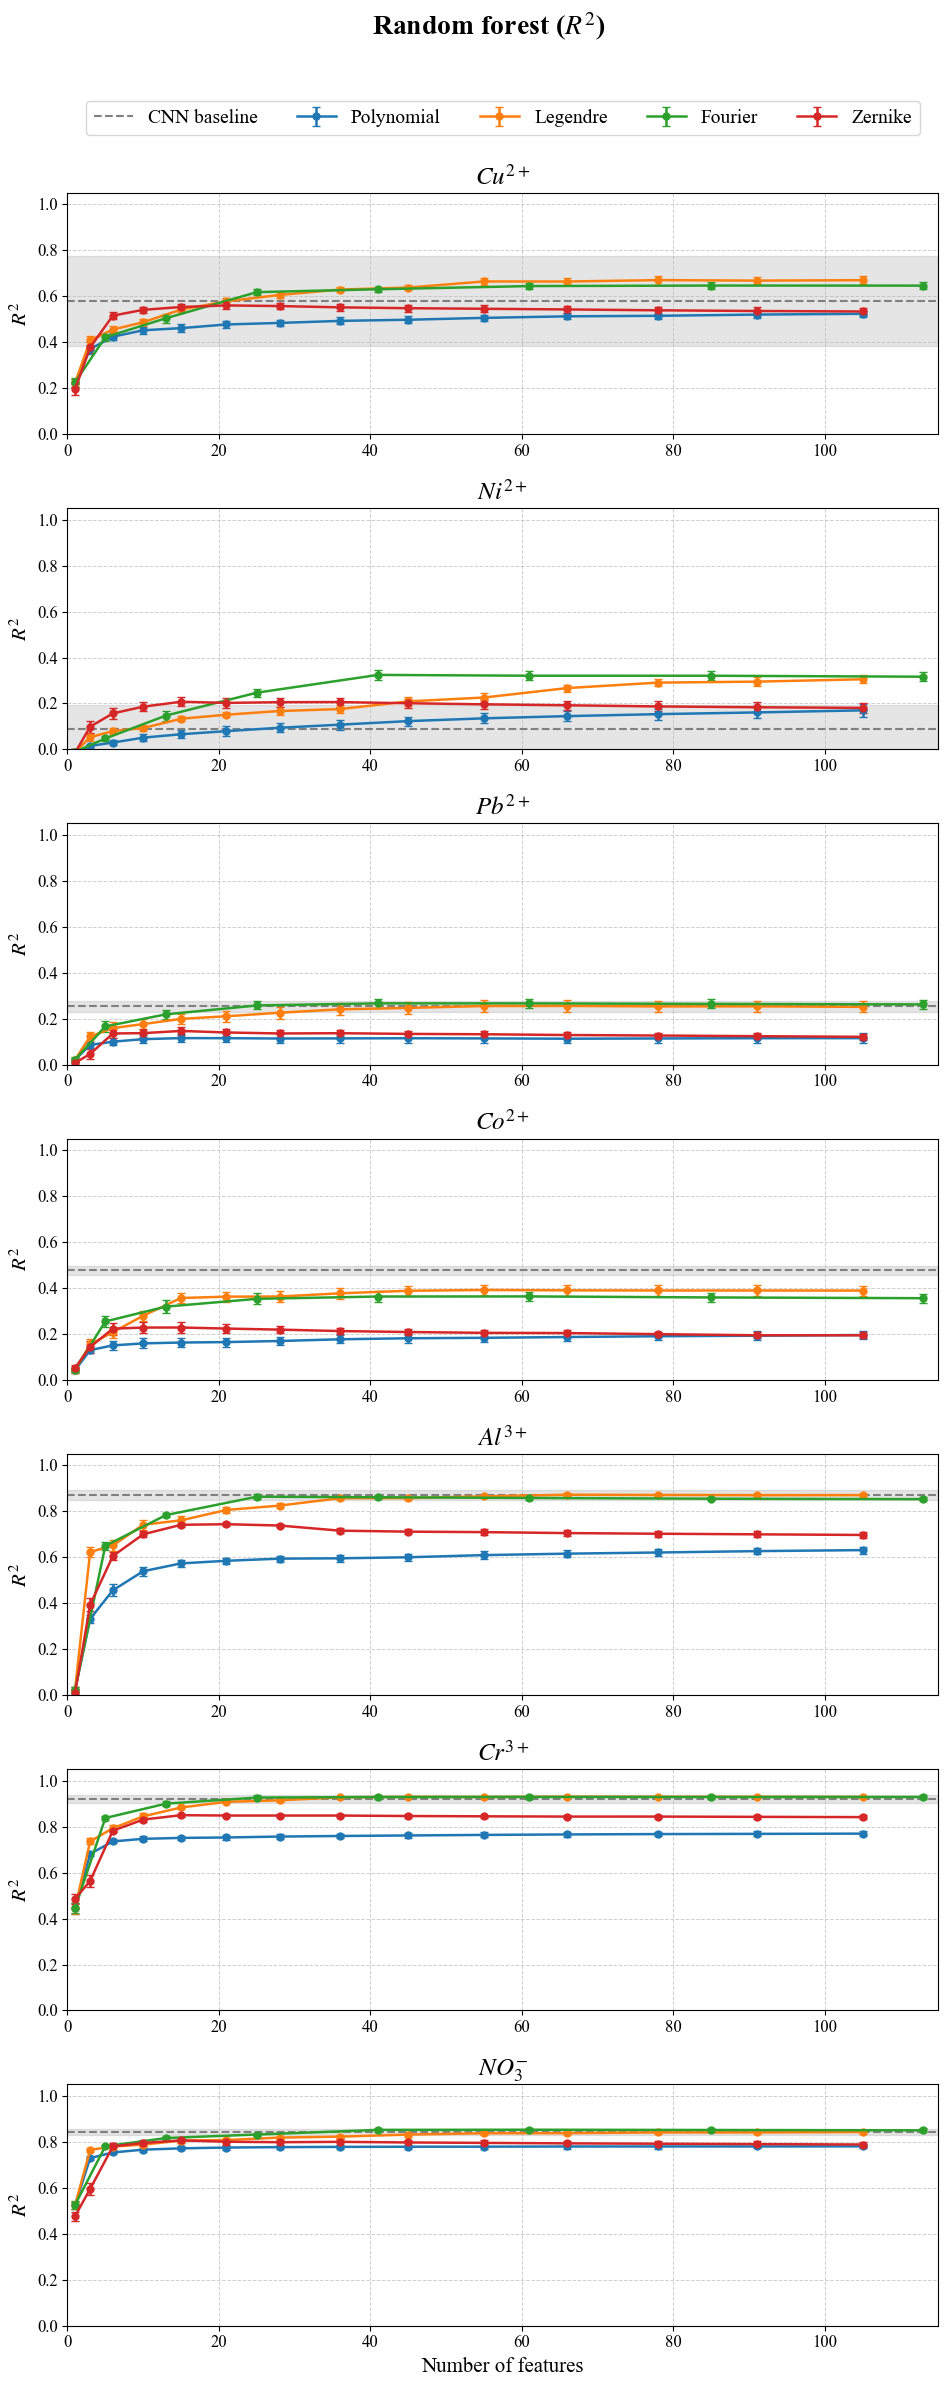

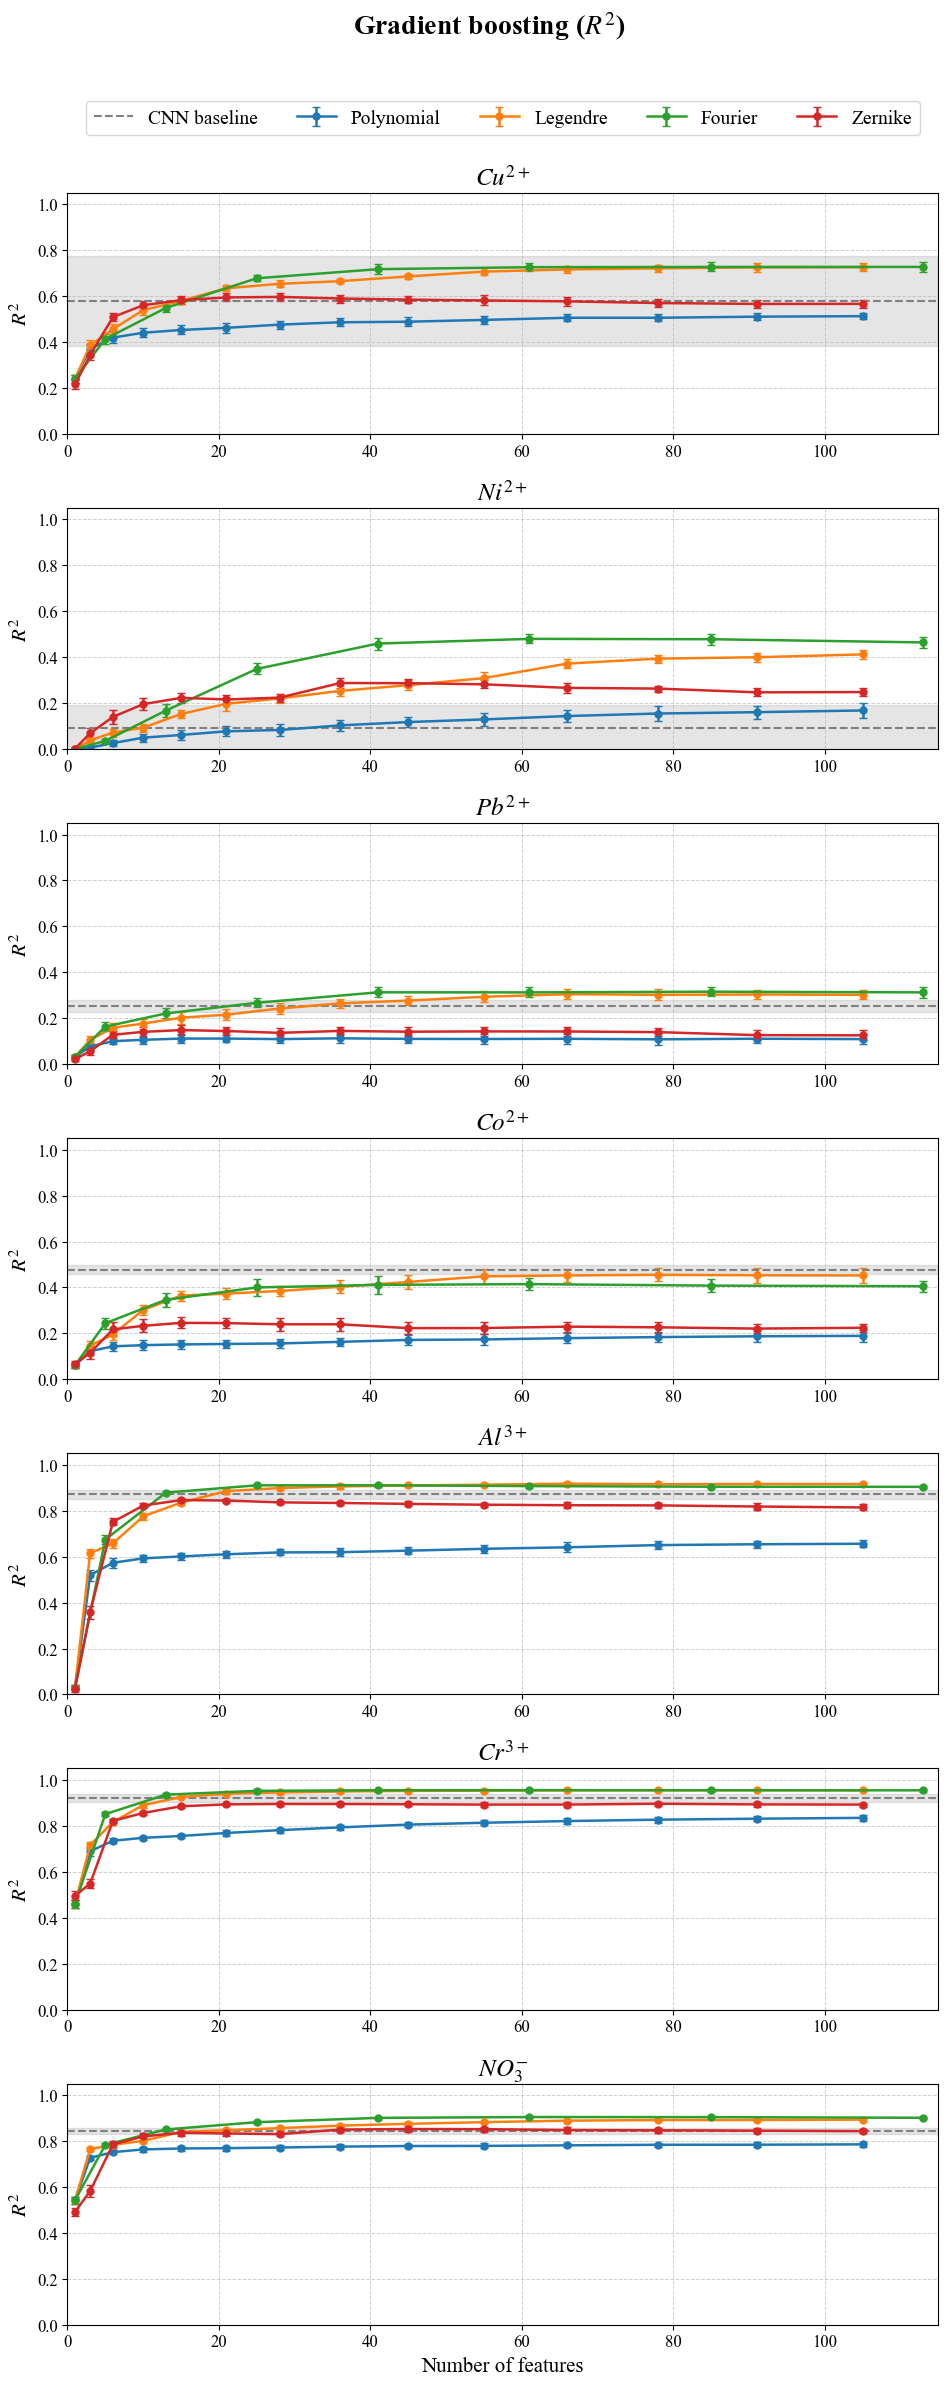

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ==================================================
# SELECT METRIC HERE
# ==================================================
METRIC = "R2"      # "MAE", "RMSE", "R2"

# ==================================================
# SEABORN PRESETS
# ==================================================
# sns.set_theme(style="whitegrid", context="poster")
# sns.set_theme(style="whitegrid", context="paper")

# ==================================================
# GLOBAL STYLE
# ==================================================
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"

mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 15
mpl.rcParams["legend.fontsize"] = 14
mpl.rcParams["xtick.labelsize"] = 12
mpl.rcParams["ytick.labelsize"] = 12

# ==================================================
# AXIS LABELS BY METRIC
# ==================================================
metric_ylabel = {
    "MAE": "MAE, mM",
    "RMSE": "RMSE, mM",
    "R2": r"$R^{2}$"
}

# ==================================================
# SETTINGS
# ==================================================
XMIN, XMAX = 0, 115

models = {
    "LR": "Linear regression",
    "RF": "Random forest",
    "GB": "Gradient boosting",
    # "MLP": "Multilayer Perceptron"
}

momenta = ["momentum", "legendre", "fourier", "zernike"]

ions = ["Cu", "Ni", "Pb", "Co", "Al", "Cr", "NO3"]

ion_titles = {
    "Cu":  r"$Cu^{2+}$",
    "Ni":  r"$Ni^{2+}$",
    "Pb":  r"$Pb^{2+}$",
    "Co":  r"$Co^{2+}$",
    "Al":  r"$Al^{3+}$",
    "Cr":  r"$Cr^{3+}$",
    "NO3": r"$NO_{3}^{-}$"
}
ion_titles = {
    "Cu":  r"$Cu^{2+}$",
    "Ni":  r"$Ni^{2+}$",
    "Pb":  r"$Pb^{2+}$",
    "Co":  r"$Co^{2+}$",
    "Al":  r"$Al^{3+}$",
    "Cr":  r"$Cr^{3+}$",
    "NO3": r"$NO_{3}^{-}$"
}

colors = {
    "momentum": "#1f77b4",
    "legendre": "#ff7f0e",
    "fourier":  "#2ca02c",
    "zernike":  "#d62728"
}

translate = {
    "momentum": "Polynomial",
    "legendre": "Legendre",
    "fourier":  "Fourier",
    "zernike":  "Zernike"
}

# ==================================================
# LOAD DATA
# ==================================================
with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

with open(BASELINE_PATH, "r") as f:
    baseline = json.load(f)

# ==================================================
# PLOT
# ==================================================
for model_key, model_title in models.items():

    if model_key not in results:
        continue

    fig, axes = plt.subplots(
        nrows=7,
        ncols=1,
        figsize=(10, 24),
        sharex=True
    )

    fig.suptitle(
        f"{model_title} ({metric_ylabel[METRIC]})",
        fontsize=20,
        fontweight="bold",
        y=0.995
    )

    for i, ion in enumerate(ions):

        ax = axes[i]

        # ------------------------------------------
        # Plot curves
        # ------------------------------------------
        for mom in momenta:

            if ion not in results[model_key][mom]:
                continue

            xs, ys, errs = [], [], []

            feature_keys = sorted(
                results[model_key][mom][ion].keys(),
                key=lambda x: int(x)
            )

            for n_feat in feature_keys:

                vals = np.array(
                    results[model_key][mom][ion][n_feat][METRIC]
                )

                xs.append(int(n_feat))
                ys.append(np.mean(vals))
                errs.append(np.std(vals))

            if len(xs) == 0:
                continue

            ax.errorbar(
                xs,
                ys,
                yerr=errs,
                marker="o",
                lw=1.8,
                ms=5,
                capsize=3,
                color=colors[mom],
                label=translate[mom]
            )

        # ------------------------------------------
        # CNN baseline
        # ------------------------------------------
        baseline_vals = np.array(baseline[ion][METRIC])

        baseline_mean = np.mean(baseline_vals)
        baseline_std  = np.std(baseline_vals)

        ax.axhline(
            baseline_mean,
            color="gray",
            linestyle="--",
            linewidth=1.5,
            label="CNN baseline"
        )

        ax.fill_between(
            [XMIN, XMAX],
            baseline_mean - baseline_std,
            baseline_mean + baseline_std,
            color="gray",
            alpha=0.20
        )

        # ------------------------------------------
        # Axes / grid
        # ------------------------------------------
        ax.set_xlim(XMIN, XMAX)

        ax.grid(
            which="major",
            axis="both",
            linestyle="--",
            linewidth=0.7,
            alpha=0.6
        )

        # Optional useful limits for R2
        if METRIC == "R2":
            ax.set_ylim(0, 1.05)

        ax.set_title(ion_titles[ion], pad=6)
        ax.set_ylabel(metric_ylabel[METRIC])

        # x labels on every subplot
        ax.tick_params(axis="x", labelbottom=True)

        # legend only first subplot
        if i == 0:
            ax.legend(
                ncol=5,
                loc="upper center",
                bbox_to_anchor=(0.5, 1.42),
                frameon=True
            )

    axes[-1].set_xlabel("Number of features")

    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

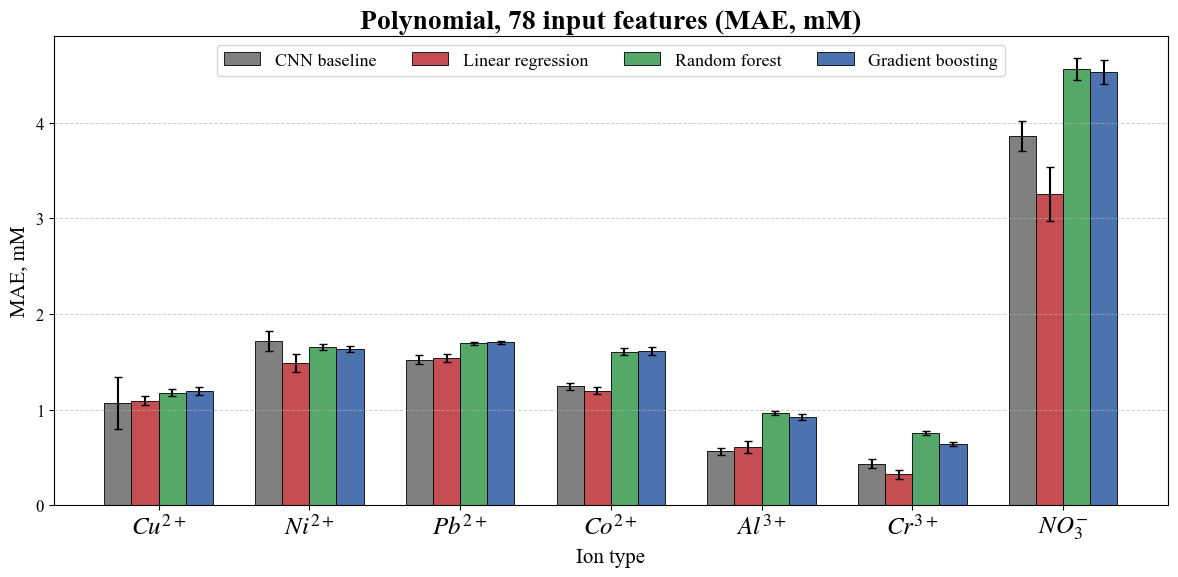

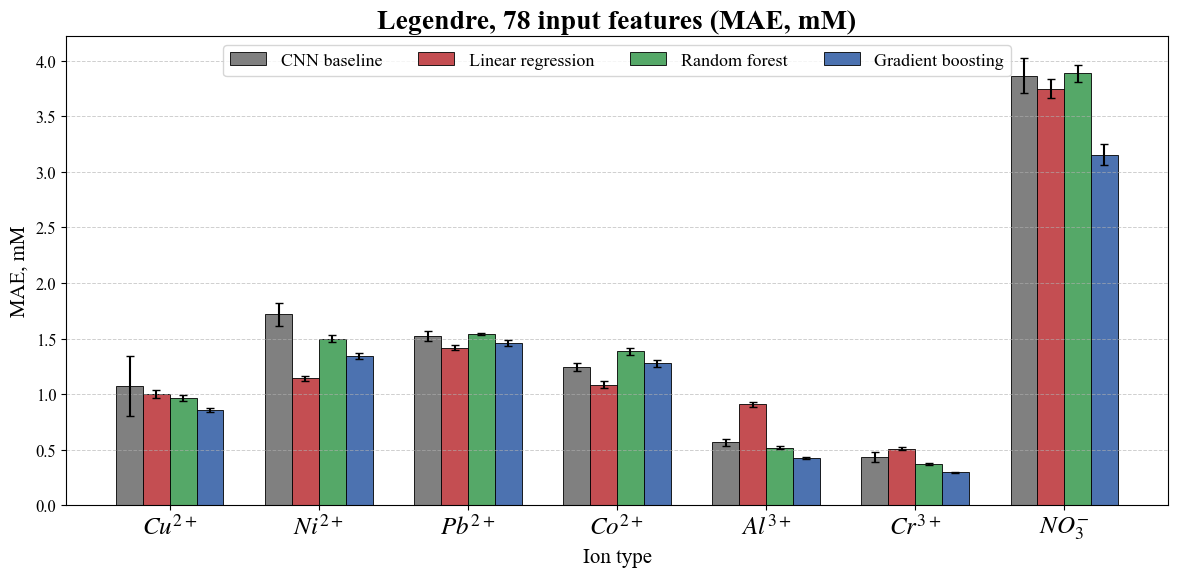

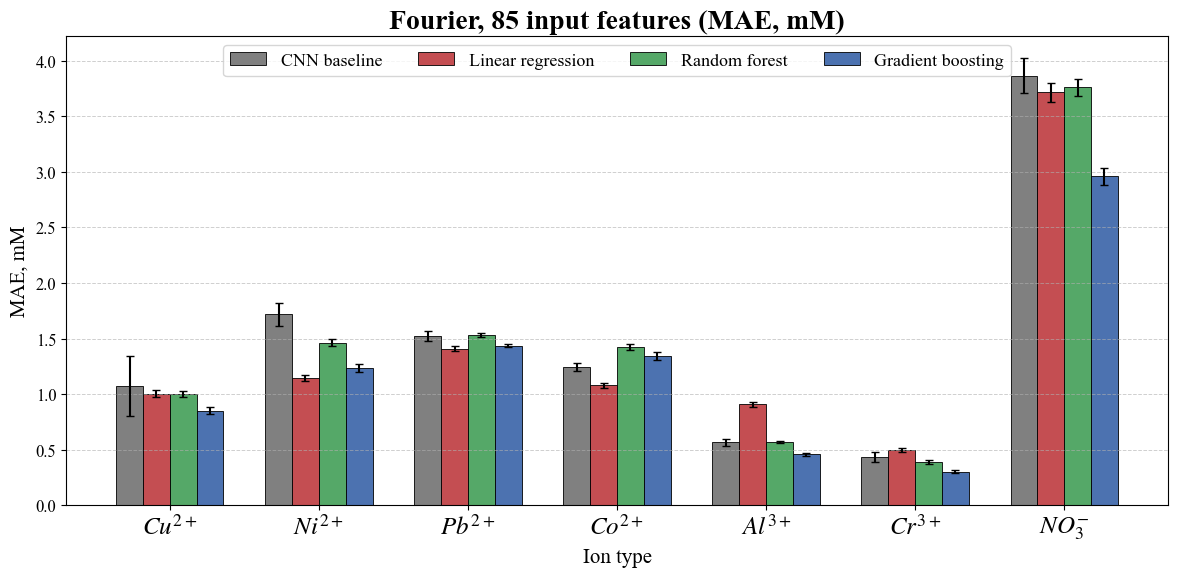

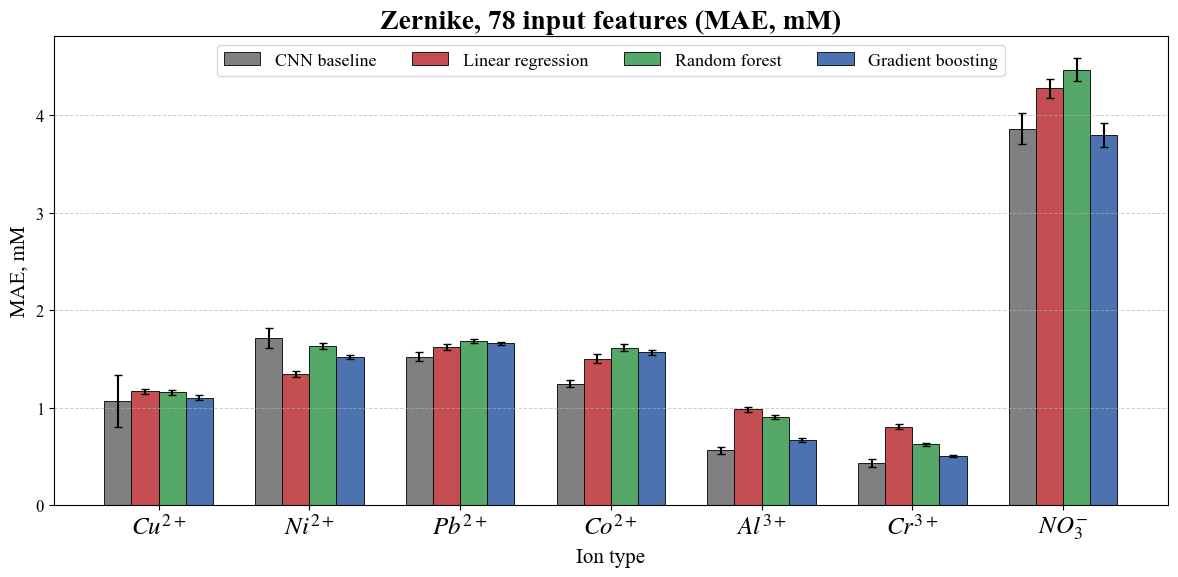

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==================================================
# STYLE
# ==================================================
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"

mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 15
mpl.rcParams["legend.fontsize"] = 13
mpl.rcParams["xtick.labelsize"] = 18   # doubled x-tick label size
mpl.rcParams["ytick.labelsize"] = 12

# ==================================================
# METRIC
# ==================================================
METRIC = "MAE"

metric_ylabel = {
    "MAE": "MAE, mM",
    "RMSE": "RMSE, mM",
    "R2": r"$R^{2}$"
}

# ==================================================
# SETUP
# ==================================================
momenta = ["momentum", "legendre", "fourier", "zernike"]

translate = {
    "momentum": "Polynomial",
    "legendre": "Legendre",
    "fourier":  "Fourier",
    "zernike":  "Zernike"
}

ions = ["Cu", "Ni", "Pb", "Co", "Al", "Cr", "NO3"]

ion_titles = {
    "Cu":  r"$Cu^{2+}$",
    "Ni":  r"$Ni^{2+}$",
    "Pb":  r"$Pb^{2+}$",
    "Co":  r"$Co^{2+}$",
    "Al":  r"$Al^{3+}$",
    "Cr":  r"$Cr^{3+}$",
    "NO3": r"$NO_{3}^{-}$"
}

models = ["CNN", "LR", "RF", "GB"]

model_titles = {
    "CNN": "CNN baseline",
    "LR": "Linear regression",
    "RF": "Random forest",
    "GB": "Gradient boosting"
}

colors = {
    "CNN": "#808080",
    "LR": "#C44E52",
    "RF": "#55A868",
    "GB": "#4C72B0",
}

# ==================================================
# DATA
# ==================================================
with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

with open(BASELINE_PATH, "r") as f:
    baseline = json.load(f)

# ==================================================
# INPUT SIZE
# ==================================================
def get_n_input(moment):
    return 85 if moment == "fourier" else 78

# ==================================================
# PLOT
# ==================================================
bar_width = 0.18
x = np.arange(len(ions))

for moment in momenta:

    n_inputs = get_n_input(moment)

    fig, ax = plt.subplots(figsize=(12, 6))

    # ------------------------------------------
    # bars per model
    # ------------------------------------------
    for j, model in enumerate(models):

        means, stds = [], []

        for ion in ions:

            if model == "CNN":
                vals = np.array(baseline[ion][METRIC])
            else:
                vals = np.array(
                    results[model][moment][ion][str(n_inputs)][METRIC]
                )

            means.append(np.mean(vals))
            stds.append(np.std(vals))

        shift = (j - (len(models) - 1) / 2) * bar_width

        ax.bar(
            x + shift,
            means,
            width=bar_width,
            yerr=stds,
            capsize=3,
            color=colors[model],
            edgecolor="black",
            linewidth=0.6,
            label=model_titles[model]
        )

    # ------------------------------------------
    # formatting
    # ------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels([ion_titles[i] for i in ions])

    ax.set_xlabel("Ion type")
    ax.set_ylabel(metric_ylabel[METRIC])

    ax.set_title(
        f"{translate[moment].capitalize()}, {n_inputs} input features ({metric_ylabel[METRIC]})", ###inputs
        fontsize=20,
        fontweight="bold",
        #pad=43   # extra spacing to avoid overlap with the legend
    )

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.6
    )

    if METRIC == "R2":
        ax.set_ylim(0, 1.05)

    # ------------------------------------------
    # legend (positioned above the title)
    # ------------------------------------------
    ax.legend(
        ncol=4,
        loc="upper center",
        #bbox_to_anchor=(0.5, 1.28),  # positioned higher
        frameon=True
    )

    plt.tight_layout()
    plt.show()

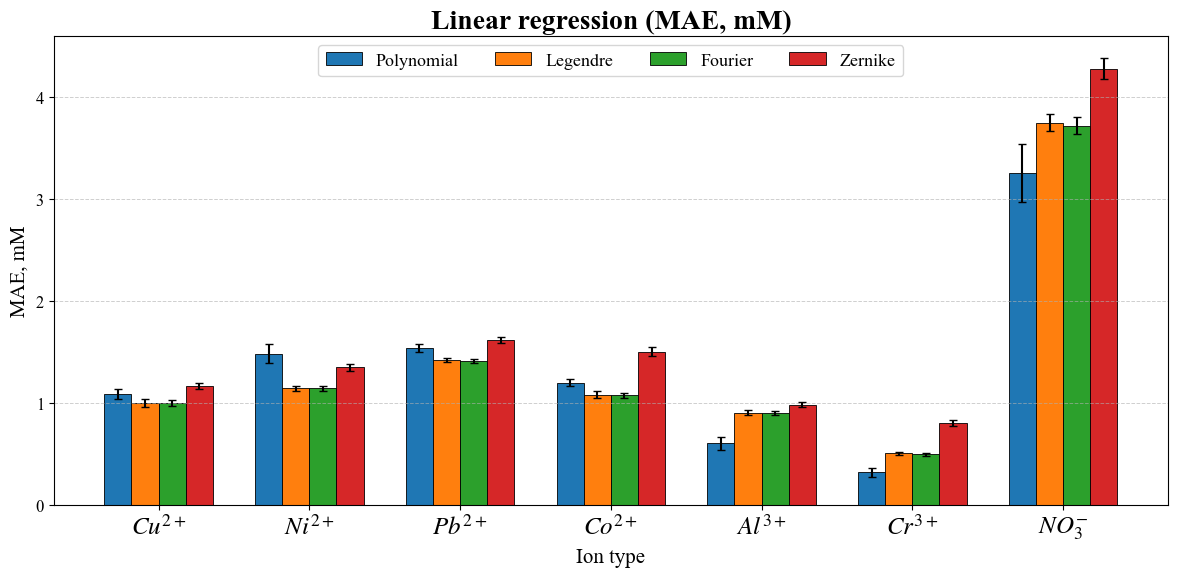

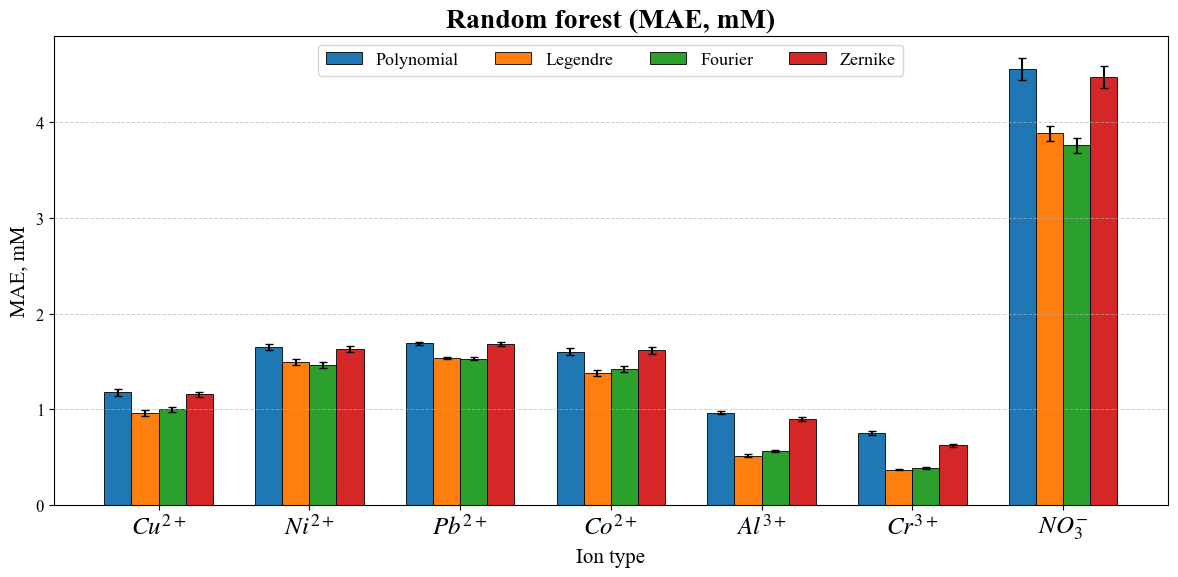

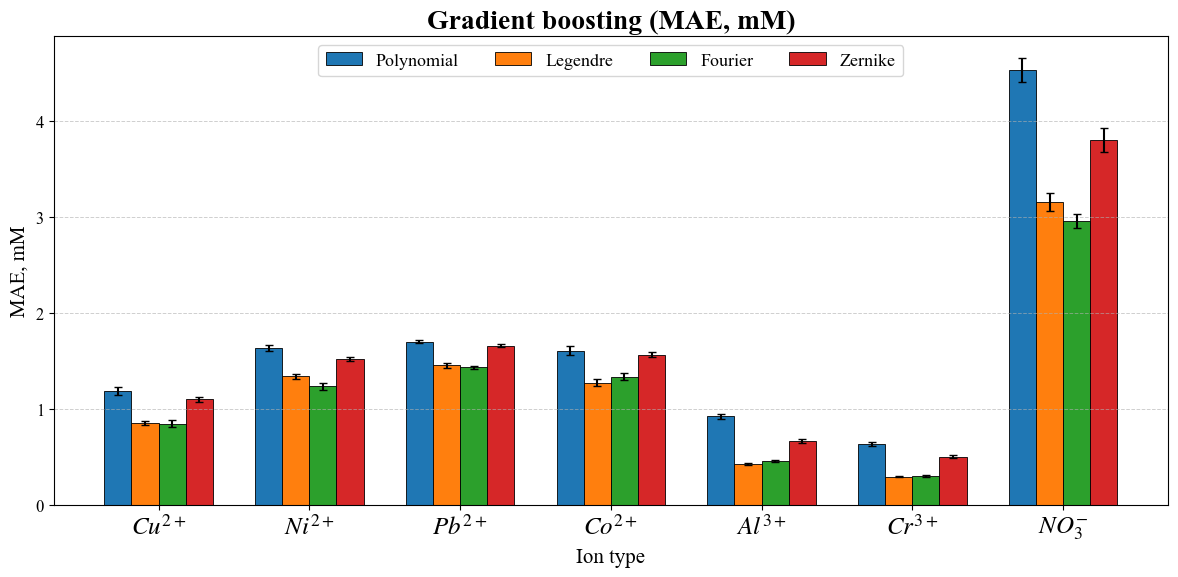

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==================================================
# STYLE
# ==================================================
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"

mpl.rcParams["font.size"] = 14
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 15
mpl.rcParams["legend.fontsize"] = 13
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 12

# ==================================================
# METRIC
# ==================================================
METRIC = "MAE"

metric_ylabel = {
    "MAE": "MAE, mM",
    "RMSE": "RMSE, mM",
    "R2": r"$R^{2}$"
}

# ==================================================
# SETUP
# ==================================================
momenta = ["momentum", "legendre", "fourier", "zernike"]


ions = ["Cu", "Ni", "Pb", "Co", "Al", "Cr", "NO3"]

ion_titles = {
    "Cu":  r"$Cu^{2+}$",
    "Ni":  r"$Ni^{2+}$",
    "Pb":  r"$Pb^{2+}$",
    "Co":  r"$Co^{2+}$",
    "Al":  r"$Al^{3+}$",
    "Cr":  r"$Cr^{3+}$",
    "NO3": r"$NO_{3}^{-}$"
}

models = ["LR", "RF", "GB"]

model_titles = {
    "LR": "Linear regression",
    "RF": "Random forest",
    "GB": "Gradient boosting"
}

colors = {
    "momentum": "#1f77b4",
    "legendre": "#ff7f0e",
    "fourier":  "#2ca02c",
    "zernike":  "#d62728"
}

translate = {
    "momentum": "Polynomial",
    "legendre": "Legendre",
    "fourier":  "Fourier",
    "zernike":  "Zernike"
}
# ==================================================
# DATA
# ==================================================
with open(RESULTS_PATH, "r") as f:
    results = json.load(f)

# ==================================================
# INPUT SIZE
# ==================================================
def get_n_input(moment):
    return "85" if moment == "fourier" else "78"

# ==================================================
# PLOT
# ==================================================
bar_width = 0.18
x = np.arange(len(ions))

for model in models:

    fig, ax = plt.subplots(figsize=(12, 6))

    n_inputs_map = {}

    # ------------------------------------------
    # bars per moment
    # ------------------------------------------
    for j, moment in enumerate(momenta):

        n_inputs = get_n_input(moment)
        n_inputs_map[moment] = n_inputs

        means, stds = [], []

        for ion in ions:

            vals = np.array(
                results[model][moment][ion][n_inputs][METRIC]
            )

            means.append(np.mean(vals))
            stds.append(np.std(vals))

        shift = (j - (len(momenta) - 1) / 2) * bar_width

        ax.bar(
            x + shift,
            means,
            width=bar_width,
            yerr=stds,
            capsize=3,
            color=colors[moment],
            edgecolor="black",
            linewidth=0.6,
            label=translate[moment]
        )

    # ------------------------------------------
    # formatting
    # ------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels([ion_titles[i] for i in ions])

    ax.set_xlabel("Ion type")
    ax.set_ylabel(metric_ylabel[METRIC])

    # title
    ax.set_title(
        f"{model_titles[model]} ({metric_ylabel[METRIC]})",
        fontsize=20,
        fontweight="bold"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.6
    )

    if METRIC == "R2":
        ax.set_ylim(0, 1.05)

    # ------------------------------------------
    # legend (moments)
    # ------------------------------------------
    ax.legend(
        ncol=4,
        loc="upper center",
        #bbox_to_anchor=(0.5, 1.12),
        frameon=True
    )

    plt.tight_layout()
    plt.show()